# GUNDAM Example on Cross-Section Extraction
---
**Goal of the exercise:** Extract the cross-section of the leading muon momentum from a dummy sample that has already been processed and cleaned. This sample contains:
 - Truth leading muon momentum (signal).
  - Reconstructed leading muon momentum from MC.
- Reconstructed leading muon momentum from fake data (same as MC).

These data has already been processed, and will be divided as follows:
- 10 truth bins × 20 reco bins (A–T)
- 16 parameters total:
    - **Template parameters:**
      - 10 template parameters (`c0`...`c9`): one per truth bin, unconstrained
    - **Nuisance parameters:**
      - 6 interaction systematics: `f_low`, `f_mid`, `f_high` with Gaussian prior σ = 10% and  `d_low`, `d_mid`, `d_high` Gaussian prior σ = 5%.

**Background types:** RES, DIS, CCother, NC, Cosmic

> **Note 1:** Random seed is fixed to 42 for reproducibility.

> **Note 2:** We will go through all steps in very much detail, and we will revisit what template and nuisance parameters mean and how they are treated in this study.

If needed, a fresh GUNDAM installation can be done cloning the repository from last year's trainning: https://github.com/JackSmedley/gundam-icarus

### Required Packages
---

In [1]:
# Required packages for this example
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import cholesky
from scipy.optimize import minimize
# Define random seed for easy reproducibility
np.random.seed(42)

### Binning
---

- Bins are defined on the `configs/binnings` directory.

- To give the fitter more freedom, we will use 1 truth bin per 2 reco bins.

In [2]:
# Bin edges and widths
true_bin_edges = np.arange(0.0, 2.1, 0.2)
true_bin_widths = np.diff(true_bin_edges)

reco_bin_edges = np.arange(0.0, 2.1, 0.1)
reco_bin_widths = np.diff(reco_bin_edges)
reco_bin_labels = [chr(65 + i) for i in range(20)]  # A–T

N_TRUE = len(true_bin_widths)   # 10 truth bins
N_RECO = len(reco_bin_widths)   # 20 reco bins

# Truth bin table
print("Truth Bins")
print(f"{'Bin':>5}  {'Range (GeV/c)':>16}  {'Width':>8}")
print("-" * 35)
for i, (lo, hi, w) in enumerate(
    zip(true_bin_edges[:-1], true_bin_edges[1:], true_bin_widths)
):
    print(f"  T{i + 1}    [{lo:.2f}, {hi:.2f}]      {w:.2f}")

print()

# Reco bin table
print("Reco Bins")
print(f"{'Bin':>5}  {'Range (GeV/c)':>16}  {'Width':>8}  {'Truth Bin':>10}")
print("-" * 50)
for j, (lo, hi, w, label) in enumerate(
    zip(reco_bin_edges[:-1], reco_bin_edges[1:], reco_bin_widths, reco_bin_labels)
):
    truth_idx = j // 2 + 1
    print(f"  {label}     [{lo:.2f}, {hi:.2f}]      {w:.2f}        T{truth_idx}")

Truth Bins
  Bin     Range (GeV/c)     Width
-----------------------------------
  T1    [0.00, 0.20]      0.20
  T2    [0.20, 0.40]      0.20
  T3    [0.40, 0.60]      0.20
  T4    [0.60, 0.80]      0.20
  T5    [0.80, 1.00]      0.20
  T6    [1.00, 1.20]      0.20
  T7    [1.20, 1.40]      0.20
  T8    [1.40, 1.60]      0.20
  T9    [1.60, 1.80]      0.20
  T10    [1.80, 2.00]      0.20

Reco Bins
  Bin     Range (GeV/c)     Width   Truth Bin
--------------------------------------------------
  A     [0.00, 0.10]      0.10        T1
  B     [0.10, 0.20]      0.10        T1
  C     [0.20, 0.30]      0.10        T2
  D     [0.30, 0.40]      0.10        T2
  E     [0.40, 0.50]      0.10        T3
  F     [0.50, 0.60]      0.10        T3
  G     [0.60, 0.70]      0.10        T4
  H     [0.70, 0.80]      0.10        T4
  I     [0.80, 0.90]      0.10        T5
  J     [0.90, 1.00]      0.10        T5
  K     [1.00, 1.10]      0.10        T6
  L     [1.10, 1.20]      0.10        T6
  M     

## Parameters Definition
---
To recover a data spectrum that is deconvoluted from detector smearing, we will compute multiple universes in where our input simulation will be varied via a set of parameters. The collection of parameters that best fit our data will be extracted. We will use two different kind of parameters:
- **Template Parameters ($c_i$):** Parametrize our signal. Modify them will alter the number of selected signal events per bin i. These parameters are free to move, no prior. We have ten truth bins, that means ten template parameters.
- **Systematic Parameters ($\vec{a}^{syst}$):** These describe systematic variations of flux, detector response, and interaction uncertainty. For this exercise we will include six interaction parameters.

Sumary of parameters for this exercise:

| Index | Name | Type
|:-----:|------|-------------
| 0–9 | `c1`...`c10` | Template
| 10 | `f_low` | Interaction
| 11 | `f_mid` | Interaction
| 12 | `f_high` | Interaction
| 13 | `d_low` | Interaction
| 14 | `d_mid` | Interaction
| 15 | `d_high` | Interaction

- Parameters are declared on the `configs/Configs_ParameterSetList` directory.
- The interaction parameters are defined on the `configs/Configs_ParameterSet/GENIE` directory.
- The template parameters are defined on the `configs/Configs_ParameterSet/Template Parameters` directory.

In [3]:
N_SYST = 6                    # 6 Interaction Systematics
N_PARAMS = N_TRUE + N_SYST    # 16

param_names = (
    [f'c{i + 1}' for i in range(N_TRUE)]
    + ['f_low', 'f_mid', 'f_high', 'd_low', 'd_mid', 'd_high']
)

# Bounds: template weights > 0, systematics unconstrained
bounds = [(1e-4, None)] * N_TRUE + [(None, None)] * N_SYST

priors = np.zeros(N_PARAMS)
sigmas = np.array([
    *[1e6] * N_TRUE,        # templates: effectively unconstrained
    0.10, 0.10, 0.10,       # interaction systematics: ±10%
    0.05, 0.05, 0.05,       # interaction systematics: ±5%
])

# Mapping from parameter index to affected truth bin indices
interaction_bins1 = {
    10: [0, 1, 2],          # f_low  → T1–T3
    11: [3, 4, 5, 6],       # f_mid  → T4–T7
    12: [7, 8, 9],          # f_high → T8–T10
}

# Mapping from parameter index to affected reco bin indices
interaction_bins2 = {
    13: list(range(0, 8)),   # d_low  → A–H
    14: list(range(8, 16)),  # d_mid  → I–P
    15: list(range(16, 20)), # d_high → Q–T
}

print(f"{'Parameter':<12} {'Prior':>8} {'Sigma':>10}")
print("-" * 34)
for k, name in enumerate(param_names):
    sigma_str = f"±{sigmas[k] * 100:.0f}%" if sigmas[k] < 1e5 else "free"
    print(f"  {name:<10}  {priors[k]:>+6.2f}  {sigma_str:>10}")

Parameter       Prior      Sigma
----------------------------------
  c1           +0.00        free
  c2           +0.00        free
  c3           +0.00        free
  c4           +0.00        free
  c5           +0.00        free
  c6           +0.00        free
  c7           +0.00        free
  c8           +0.00        free
  c9           +0.00        free
  c10          +0.00        free
  f_low        +0.00        ±10%
  f_mid        +0.00        ±10%
  f_high       +0.00        ±10%
  d_low        +0.00         ±5%
  d_mid        +0.00         ±5%
  d_high       +0.00         ±5%


### MC INPUTS
---
Now let's take a look at our input data ready for GUNDAM.
 - Truth leading muon momentum (signal).
  - Reconstructed leading muon momentum from MC.
- Reconstructed leading muon momentum from fake data (same as MC).

The specific data can be found in the code block below. We are doing an ASIMOV study, so data = MC. **So far nothing new, you already have this from your PANDORA/SPINE selection.**

- First we add our datasets (the selection/signal/sideband trees from our root file) on the `configs/Configs_DataSetList` directory.
- Now we define our fit sample on the `configs/Configs_FitSampleSet` directory.


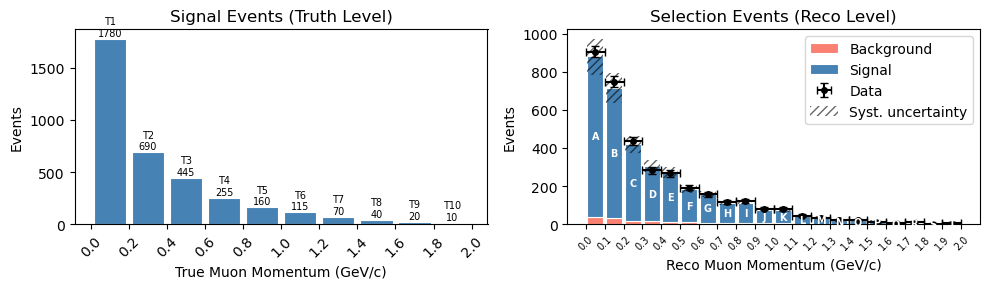

In [4]:
# Truth-level signal counts — falling spectrum
N_true_gen = np.array([1780., 690., 445., 255., 160., 115., 70., 40., 20., 10.])

# Migration matrix: shape (N_TRUE, N_RECO), 2 reco bins per truth bin
N_ij = np.array([
    # A      B      C      D      E      F      G      H      I      J      K      L      M      N      O      P      Q      R      S      T
    [800.,  650.,   80.,   20.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T1
    [ 40.,   30.,  300.,  250.,   30.,   10.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T2
    [  0.,    5.,   20.,   15.,  220.,  150.,   20.,   10.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T3
    [  0.,    0.,    0.,    5.,   10.,   10.,  120.,   80.,   15.,    5.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T4
    [  0.,    0.,    0.,    0.,    0.,    5.,   10.,   10.,   80.,   50.,   10.,    5.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T5
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    5.,   10.,   10.,   55.,   30.,    5.,    2.,    0.,    0.,    0.,    0.,    0.,    0.],  # T6
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    5.,    5.,    5.,   30.,   15.,    5.,    2.,    0.,    0.,    0.,    0.],  # T7
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    3.,    3.,    3.,   15.,   10.,    2.,    1.,    0.,    0.],  # T8
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    2.,    2.,    2.,    6.,    4.,    1.,    0.],  # T9
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    2.,    1.,    1.,    2.,    2.],  # T10
], dtype=np.float64)

# Efficiency per truth bin
eff = N_ij.sum(axis=1) / N_true_gen

# Reco-level background counts and types
B_j = np.array([40., 30., 18., 15., 12., 10., 8., 7., 6., 5., 4., 3., 3., 2., 2., 2., 1., 1., 1., 1.])
B_type = [
    'RES', 'RES', 'RES', 'RES',
    'DIS', 'DIS', 'DIS', 'DIS',
    'CCother', 'CCother', 'CCother', 'CCother',
    'NC', 'NC', 'NC', 'NC',
    'Cosmic', 'Cosmic', 'Cosmic', 'Cosmic',
]

# Predicted signal and total MC counts
N_mc_signal = N_ij.sum(axis=0)
N_mc_total = N_mc_signal + B_j

# Asimov-like fake data: MC total
#N_data = N_mc_total

# Fake data: Poisson fluctuation around MC total (Asimov = N_mc_total, no fluctuation)
rng = np.random.default_rng(seed=42)
N_data = rng.poisson(N_mc_total).astype(np.float64)

# Bin centers for plotting
true_centers = 0.5 * (true_bin_edges[:-1] + true_bin_edges[1:])
reco_centers = 0.5 * (reco_bin_edges[:-1] + reco_bin_edges[1:])

# ── Reco-level group definitions for systematic toys ─────────────────────────
# Interaction groups span reco bins for each interaction systematic parameter
int_groups1 = [list(range(0, 6)), list(range(6, 14)), list(range(14, 20))]
int_groups2 = [list(range(0, 8)), list(range(8, 16)), list(range(16, 20))]

# ── Pre-fit systematic uncertainty band (signal region) ───────────────────────
N_BAND_TOYS = 2000  # number of toys for pre-fit uncertainty band
pred_toys = np.zeros((N_BAND_TOYS, N_RECO))
for k in range(N_BAND_TOYS):
    int_shifts1 = np.random.normal(0.0, 0.10, size=3)
    int_shifts2 = np.random.normal(0.0, 0.05, size=3)
    int_w1 = np.ones(N_RECO)
    int_w2 = np.ones(N_RECO)
    for g in range(3):
        int_w1[int_groups1[g]] *= (1 + int_shifts1[g])
        int_w2[int_groups2[g]] *= (1 + int_shifts2[g])
    pred_toys[k] = N_mc_signal * int_w1 * int_w2 + B_j

pred_mean = np.mean(pred_toys, axis=0)
pred_std = np.std(pred_toys, axis=0)

# ── Signal region histograms ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Left: truth-level signal
ax = axes[0]
ax.bar(
    true_centers, N_true_gen,
    width=true_bin_widths * 0.85,
    color='steelblue', edgecolor='white', linewidth=0.8,
)
ax.set_xlabel('True Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Signal Events (Truth Level)')
ax.set_xticks(true_bin_edges)
ax.tick_params(axis='x', rotation=45)
for i, (x, y) in enumerate(zip(true_centers, N_true_gen)):
    ax.text(x, y + 10, f'T{i + 1}\n{int(y)}', ha='center', va='bottom', fontsize=7)

# Right: reco-level selection with stacked signal/background and data
ax = axes[1]
ax.bar(
    reco_centers, B_j,
    width=reco_bin_widths * 0.85,
    color='salmon', edgecolor='white', linewidth=0.8, label='Background',
)
ax.bar(
    reco_centers, N_mc_signal,
    width=reco_bin_widths * 0.85,
    bottom=B_j, color='steelblue', edgecolor='white', linewidth=0.8, label='Signal',
)
ax.errorbar(
    reco_centers, N_data,
    yerr=np.sqrt(N_data), xerr=reco_bin_widths / 2,
    fmt='ko', markersize=4, capsize=3, label='Data',
)
ax.bar(
    reco_centers, 2 * pred_std,
    width=reco_bin_widths * 0.85,
    bottom=pred_mean - pred_std,
    color='none', edgecolor='black', linewidth=0,
    hatch='////', alpha=0.6, label='Syst. uncertainty',
)
for j, (x, sig, bkg) in enumerate(zip(reco_centers, N_mc_signal, B_j)):
    ax.text(
        x, bkg + sig / 2, reco_bin_labels[j],
        ha='center', va='center', fontsize=7, color='white', fontweight='bold',
    )
ax.set_xlabel('Reco Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Selection Events (Reco Level)')
ax.set_xticks(reco_bin_edges)
ax.set_xticklabels([f'{x:.1f}' for x in reco_bin_edges], rotation=45, fontsize=7)
ax.legend()

plt.tight_layout()
plt.show()


Similar story with your sideband.

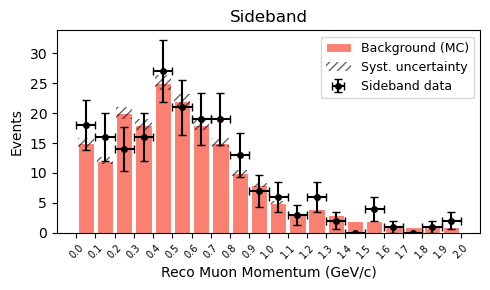

In [5]:
# ── Sideband inputs ───────────────────────────────────────────────────────────
# Sideband region (e.g. events with pions), same reco binning
B_sb = np.array([15., 12., 20., 18., 25., 22., 18., 15., 10., 8., 5., 3., 4., 3., 2., 2., 1., 1., 1., 1.])
B_sb_type = [
    'RES', 'RES', 'RES', 'RES',
    'DIS', 'DIS', 'DIS', 'DIS',
    'CCother', 'CCother', 'CCother', 'CCother',
    'NC', 'NC', 'NC', 'NC',
    'Cosmic', 'Cosmic', 'Cosmic', 'Cosmic',
]
# Fake data: Poisson fluctuation around MC total (Asimov = N_mc_total, no fluctuation)
rng = np.random.default_rng(seed=42)
N_sb_data = rng.poisson(B_sb).astype(np.float64)

# Interaction groups for sideband (12 bins only)
det_groups_sb = [list(range(0, 4)), list(range(4, 8)), list(range(8, 12))]

# ── Pre-fit sideband uncertainty band ─────────────
sb_pred_toys = np.zeros((N_BAND_TOYS, len(B_sb)))
for k in range(N_BAND_TOYS):
    int_shifts2 = np.random.normal(0.0, 0.05, size=3)
    int_w2 = np.ones(len(B_sb))
    for g in range(3):
        int_w2[det_groups_sb[g]] *= (1 + int_shifts2[g])
    sb_pred_toys[k] = B_sb * int_w2

sb_pred_mean = np.mean(sb_pred_toys, axis=0)
sb_pred_std = np.std(sb_pred_toys, axis=0)

# ── Sideband histogram ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(
    reco_centers, B_sb,
    width=reco_bin_widths * 0.85,
    color='salmon', edgecolor='white', linewidth=0.8, label='Background (MC)',
)
ax.bar(
    reco_centers, 2 * sb_pred_std,
    width=reco_bin_widths * 0.85,
    bottom=sb_pred_mean - sb_pred_std,
    color='none', edgecolor='black', linewidth=0,
    hatch='////', alpha=0.6, label='Syst. uncertainty',
)
ax.errorbar(
    reco_centers, N_sb_data,
    yerr=np.sqrt(N_sb_data), xerr=reco_bin_widths / 2,
    fmt='ko', markersize=4, capsize=3, label='Sideband data',
)
ax.set_xlabel('Reco Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Sideband')
ax.set_xticks(reco_bin_edges)
ax.set_xticklabels([f'{x:.1f}' for x in reco_bin_edges], rotation=45, fontsize=7)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Event Counts Prediction
---
After running our detector, we count how many events land in each
**reconstructed bin** $j$. But before comparing to data, we need a
way to *predict* those counts from our simulation. That prediction
is called $N_j^\text{sim}$.

$$N_j^\text{sim} = \sum_i \left(c_i w_i^\text{sig} N_i^\text{sim\,sig} + w_i^\text{bkg} N_i^\text{sim\,bkg}\right) U_{ij}$$

Think of this as a **recipe with four ingredients** per true bin $i$:
| Symbol | Plain English |
|:------:|---------------|
| $N_i^\text{sim\,sig}$ | How many **signal** events the simulation puts in true bin $i$ |
| $N_i^\text{sim\,bkg}$ | How many **background** events the simulation puts in true bin $i$ |
| $c_i$ | Our template parameters, the **tuning knob** for the signal |
| $w_i^\text{sig}$, $w_i^\text{bkg}$ | **Systematic weights** — how much do interaction effects stretch the prediction? |
| $U_{ij}$ | The **smearing matrix** — probability that a true-bin-$i$ event ends up measured in reco bin $j$ |



In [6]:
def forward_model(params):
    """
    Predict reco-level event counts given all 16 parameters.

    Parameters
    ----------
    params : np.ndarray, shape (N_PARAMS,)
        Parameter vector ordered as:
        [c0..c9, f_low, f_mid, f_high, d_low, d_mid, d_high]

    Returns
    -------
    np.ndarray, shape (N_RECO,)
        Predicted event counts per reco bin (signal + background).

    Notes
    -----
    Forward model steps:

    1. Each truth bin i scaled by template weight c_i
    2. Interaction weight 1 applied per truth-bin group (T1–T3, T4–T7, T8–T10)
    3. Migration matrix projects truth → reco space
    4. Interaction weight 2 applied per reco-bin group (A–H, I–P, Q–T)
    5. Fixed background B_j added
    """
    c = params[:N_TRUE]
    f_low, f_mid, f_high = params[N_TRUE:N_TRUE + 3]
    d_low, d_mid, d_high = params[N_TRUE + 3:N_TRUE + 6]

    # Interaction weight vector 1, one per truth bin
    int_w1 = np.array([
        1 + f_low,  1 + f_low,  1 + f_low,              # T1–T3
        1 + f_mid,  1 + f_mid,  1 + f_mid,  1 + f_mid,  # T4–T7
        1 + f_high, 1 + f_high, 1 + f_high,             # T8–T10
    ])

    # Interaction weight vector 2, one per reco bin
    int_w2 = np.array([
        *[1 + d_low]  * 8,   # A–H
        *[1 + d_mid]  * 8,   # I–P
        *[1 + d_high] * 4,   # Q–T
    ])

    # Vectorised truth → reco projection: sum_i c_i * int_w1_i * N_ij[i, :]
    N_signal = (c * int_w1) @ N_ij

    return N_signal * int_w2 + B_j


# ── Nominal check (all c=1, all systematics=0) ────────────────────────────────
params_init = np.zeros(N_PARAMS)
params_init[:N_TRUE] = 1.0
N_pred_init = forward_model(params_init)

print(f"{'Bin':<5}  {'Momentum Range (GeV/c)':>22}  {'Nominal Prediction':>20}  {'Observed Data':>15}")
print("-" * 70)
for label, lo, hi, pred, obs in zip(
    reco_bin_labels,
    reco_bin_edges[:-1],
    reco_bin_edges[1:],
    N_pred_init,
    N_data,
):
    print(f"  {label:<3}  [{lo:.1f}, {hi:.1f}]  {pred:>20.1f}  {int(obs):>15.1f}")

Bin    Momentum Range (GeV/c)    Nominal Prediction    Observed Data
----------------------------------------------------------------------
  A    [0.0, 0.1]                 880.0            905.0
  B    [0.1, 0.2]                 715.0            748.0
  C    [0.2, 0.3]                 418.0            434.0
  D    [0.3, 0.4]                 305.0            282.0
  E    [0.4, 0.5]                 272.0            266.0
  F    [0.5, 0.6]                 185.0            191.0
  G    [0.6, 0.7]                 158.0            156.0
  H    [0.7, 0.8]                 112.0            114.0
  I    [0.8, 0.9]                 111.0            122.0
  J    [0.9, 1.0]                  75.0             82.0
  K    [1.0, 1.1]                  74.0             82.0
  L    [1.1, 1.2]                  46.0             45.0
  M    [1.2, 1.3]                  41.0             33.0
  N    [1.3, 1.4]                  24.0             21.0
  O    [1.4, 1.5]                  24.0             23.0
  P  

### Minimum Likelihood Calculation
---

The total likelihood is defined as:

$$-2\log(L) = -2\log(L_\text{stat}^\text{signal}) - 2\log(L_\text{stat}^\text{sideband}) - 2\log(L_\text{syst})$$

- Term 1 — Signal region: $$-2\log(L)_\text{stat}^\text{signal} = \sum_j^\text{reco bins} 2\!\left(N_j^\text{sim} - N_j^\text{obs} + N_j^\text{obs}\log\frac{N_j^\text{obs}}{N_j^\text{sim}}\right)$$

- Term 2 — Sideband region: A sideband is a **signal-free control region** (e.g. events with pions)
that shares the same systematics as our signal region.
Fitting it simultaneously gives us a data-driven constraint on
systematics parameters *before* they are applied to the signal region. $$-2\log(L)_\text{stat}^\text{sideband} = \sum_j^\text{reco bins} 2\!\left(B_j^\text{sim} - B_j^\text{obs} + B_j^\text{obs}\log\frac{B_j^\text{obs}}{B_j^\text{sim}}\right)$$

where $B_j^\text{sim} = w_j^\text{det} \cdot B_j^\text{nom}$ is the
background prediction scaled only by detector weights — no signal
template or interaction terms appear here.

- Term 3 — Systematic penalty : $$-2\log(L)_\text{syst} = (\vec{a}^\text{syst} - \vec{a}^\text{syst}_\text{prior})(V^\text{syst}_\text{prior})^{-1}(\vec{a}^\text{syst} - \vec{a}^\text{syst}_\text{prior})$$

- The fitter is initialized on the file: `config_Fitter_FakeData_dpT.yaml` (or whatever name you define for it) and is runned by:
```bash
gundamFitter -c {fitter yaml file} -o {output .root file} -a
```
For example:
```bash
gundamFitter -c config_Fitter_FakeData_dpT.yaml -o asimov_dpT.root -a
```

In [15]:
def forward_model_sideband(params):
    """
    Predict sideband counts under interaction systematics.

    Parameters
    ----------
    params : np.ndarray, shape (N_PARAMS,)
        Full parameter vector; only d_low, d_mid, d_high are used.

    Returns
    -------
    np.ndarray, shape (N_RECO,)
        Predicted sideband counts per reco bin.
    """
    d_low, d_mid, d_high = params[N_TRUE + 3], params[N_TRUE + 4], params[N_TRUE + 5]
    int_w2 = np.array([
        *[1 + d_low]  * 8,   # A–H
        *[1 + d_mid]  * 8,   # I–P
        *[1 + d_high] * 4,   # Q–T
    ])
    return B_sb * int_w2

def neg_log_likelihood(params):
    """
    Compute the signal region negative log-likelihood (Poisson + Gaussian penalties).

    Uses the Baker-Cousins log-likelihood ratio statistic:
        2 * sum_j [ N_pred_j - N_obs_j + N_obs_j * ln(N_obs_j / N_pred_j) ]

    Gaussian penalty terms are applied to systematic parameters only
    (indices N_TRUE through N_PARAMS).

    Parameters
    ----------
    params : np.ndarray, shape (N_PARAMS,)
        Current parameter values.

    Returns
    -------
    float
        Total -2 ln L value.
    """
    # ── Signal region ─────────────────────────────────────────────────────────
    N_pred = forward_model(params)
    valid = (N_pred > 0) & (N_data > 0)
    L_signal = np.sum(
        2.0 * (N_pred[valid] - N_data[valid]
               + N_data[valid] * np.log(N_data[valid] / N_pred[valid]))
    )
    zero_data = (N_pred > 0) & (N_data <= 0)
    L_signal += 2.0 * np.sum(N_pred[zero_data])

    # ── Sideband region ───────────────────────────────────────────────────────
    N_pred_sb = forward_model_sideband(params)
    valid_sb = (N_pred_sb > 0) & (N_sb_data > 0)
    L_sideband = np.sum(
        2.0 * (N_pred_sb[valid_sb] - N_sb_data[valid_sb]
               + N_sb_data[valid_sb] * np.log(N_sb_data[valid_sb] / N_pred_sb[valid_sb]))
    )
    zero_data_sb = (N_pred_sb > 0) & (N_sb_data <= 0)
    L_sideband += 2.0 * np.sum(N_pred_sb[zero_data_sb])

    # ── Systematic penalties ──────────────────────────────────────────────────
    syst_slice = slice(N_TRUE, N_PARAMS)
    L_penalty = np.sum(
        ((params[syst_slice] - priors[syst_slice]) / sigmas[syst_slice]) ** 2
    )

    return L_signal + L_sideband + L_penalty


L_init = neg_log_likelihood(params_init)
print(f"Initial -2logL: {L_init:.4f}")

Initial -2logL: 34.9280


### Minimization
---

In [8]:
result_main = minimize(
    neg_log_likelihood,
    params_init,
    method='L-BFGS-B',
    bounds=bounds,
    options={'ftol': 1e-12, 'gtol': 1e-8, 'maxiter': 10000},
)
params_best = result_main.x
L_best = result_main.fun
N_pred_best = forward_model(params_best)

# This step reports results and compares to the nominal prediction.
print(f"Converged: {result_main.success}  ({result_main.message})")
print(f"Final -2logL: {L_best:.4f}  (improvement: {L_init - L_best:.2f})")
print()

# ── Parameter summary table ───────────────────────────────────────────────────
print(f"{'Parameter':<12} {'Value':>10} {'Pull (σ)':>10}")
print("-" * 36)
for k, name in enumerate(param_names):
    val = params_best[k]
    is_constrained = sigmas[k] < 1e5
    if is_constrained:
        pull = (val - priors[k]) / sigmas[k]
        print(f"  {name:<10}  {val:>+10.4f}  {pull:>+10.2f}σ")
    else:
        print(f"  {name:<10}  {val:>+10.4f}  {'(free)':>10}")

# ── Data vs best-fit residuals ────────────────────────────────────────────────
print()
print(f"{'Bin':<5} {'Data':>8} {'MC nominal':>12} {'Best-fit':>12} {'Residual':>10}")
print("-" * 52)
for label, obs, nom, pred in zip(
    reco_bin_labels, N_data, N_pred_init, N_pred_best
):
    resid = (obs - pred) / np.sqrt(obs)
    print(f"  {label:<3}  {obs:>8.0f}  {nom:>12.1f}  {pred:>12.2f}  {resid:>+10.2f}")

Converged: True  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)
Final -2logL: 26.6961  (improvement: 8.23)

Parameter         Value   Pull (σ)
------------------------------------
  c1             +1.0333      (free)
  c2             +0.9640      (free)
  c3             +0.9928      (free)
  c4             +0.9711      (free)
  c5             +1.1313      (free)
  c6             +1.0863      (free)
  c7             +0.7695      (free)
  c8             +0.8218      (free)
  c9             +0.7927      (free)
  c10            +1.1248      (free)
  f_low          +0.0000       +0.00σ
  f_mid          -0.0000       -0.00σ
  f_high         -0.0000       -0.00σ
  d_low          +0.0098       +0.20σ
  d_mid          +0.0067       +0.13σ
  d_high         +0.0016       +0.03σ

Bin       Data   MC nominal     Best-fit   Residual
----------------------------------------------------
  A         905         880.0        913.73       -0.29
  B         748         715.0        742.48       +0

### Hessian and Uncertainties
---
After minimising $-2\log(L)$, we know the **best-fit parameters**
$\hat{\theta}$. But we also need to know how *uncertain* those
parameters are. The Hessian is the key to extracting that information. The Hessian $H$ is the matrix of second derivatives of $-2\log(L)$
evaluated at the minimum:

$$H_{ij} = \left.\frac{\partial^2(-2\log L)}{\partial \theta_i \,\partial \theta_j}\right|_{\hat{\theta}}$$

It measures **how sharply curved** the likelihood is around the minimum
in every parameter direction. A steep curvature means the parameter is
well-constrained; a shallow curvature means it is poorly constrained.

Near the minimum, the likelihood is approximately parabolic (Gaussian
approximation). In this regime the **covariance matrix** $V$ is simply
the inverse of the Hessian:

$$V = H^{-1}$$

This is the standard result from maximum likelihood theory — the
inverse Hessian of $-2\log L$ gives the parameter covariance matrix.

The **1σ uncertainty** on each parameter $\theta_i$ is:

$$\sigma_i = \sqrt{V_{ii}} = \sqrt{(H^{-1})_{ii}}$$

This is what `err = np.sqrt(np.diag(V_main))` computes.

The covariance matrix mixes units across parameters. To compare
relationships between parameters on equal footing, we normalise
into a **correlation matrix**:

$$\rho_{ij} = \frac{V_{ij}}{\sigma_i \sigma_j}$$

where $\rho_{ij} \in [-1, +1]$:

| Value | Meaning |
|:-----:|---------|
| $\rho = +1$ | Parameters move together — fully correlated |
| $\rho = 0$  | Parameters are independent |
| $\rho = -1$ | Parameters move oppositely — fully anti-correlated |

In [9]:
HESSIAN_EPS = 1e-5       # finite-difference step for Hessian computation
N_POSTFIT_TOYS = 2000    # number of toys for post-fit uncertainty bands

def compute_hessian(likelihood_fn, params, eps=HESSIAN_EPS):
    """
    Compute the Hessian of a likelihood function by finite differences.

    Uses a second-order central difference for diagonal elements and a
    four-point mixed partial for off-diagonal elements.

    Parameters
    ----------
    likelihood_fn : callable
        Scalar function of a 1-D parameter array.
    params : np.ndarray, shape (n,)
        Parameter values at which to evaluate the Hessian.
    eps : float, optional
        Finite-difference step size. Default is 1e-5.

    Returns
    -------
    H : np.ndarray, shape (n, n)
        Symmetric Hessian matrix.
    """
    n = len(params)
    H = np.zeros((n, n))
    f0 = likelihood_fn(params)

    for i in range(n):
        for j in range(i, n):
            if i == j:
                p_p = params.copy(); p_p[i] += eps
                p_m = params.copy(); p_m[i] -= eps
                H[i, i] = (likelihood_fn(p_p) - 2 * f0 + likelihood_fn(p_m)) / eps ** 2
            else:
                p_pp = params.copy(); p_pp[i] += eps; p_pp[j] += eps
                p_pm = params.copy(); p_pm[i] += eps; p_pm[j] -= eps
                p_mp = params.copy(); p_mp[i] -= eps; p_mp[j] += eps
                p_mm = params.copy(); p_mm[i] -= eps; p_mm[j] -= eps
                H[i, j] = (
                    likelihood_fn(p_pp) - likelihood_fn(p_pm)
                    - likelihood_fn(p_mp) + likelihood_fn(p_mm)
                ) / (4 * eps ** 2)
                H[j, i] = H[i, j]
    return H

# ── Main fit Hessian & covariance ─────────────────────────────────────────────
print("Computing main fit Hessian...")
H_main = compute_hessian(neg_log_likelihood, params_best)
V_main = np.linalg.inv(H_main)
err = np.sqrt(np.diag(V_main))
L_chol = cholesky(V_main, lower=True)

print(f"\n{'Parameter':<12} {'Best-fit':>12} {'Uncertainty':>14}")
print("-" * 42)
for k, name in enumerate(param_names):
    print(f"  {name:<10}  {params_best[k]:>+12.4f}  ±{err[k]:>12.4f}")

# Template–template correlation matrix
print("\nFull correlation matrix:")
print(f"{'':12}", end='')
for name in param_names:
    print(f"  {name:<8}", end='')
print()
for i, name_i in enumerate(param_names):
    print(f"  {name_i:<10}", end='')
    for j in range(N_PARAMS):
        rho = V_main[i, j] / (err[i] * err[j])
        print(f"  {rho:+.2f}", end='')
    print()

Computing main fit Hessian...

Parameter        Best-fit    Uncertainty
------------------------------------------
  c1               +1.0333  ±      0.0818
  c2               +0.9640  ±      0.0817
  c3               +0.9928  ±      0.0868
  c4               +0.9711  ±      0.0971
  c5               +1.1313  ±      0.1230
  c6               +1.0863  ±      0.1300
  c7               +0.7695  ±      0.1380
  c8               +0.8218  ±      0.1993
  c9               +0.7927  ±      0.2990
  c10              +1.1248  ±      0.4457
  f_low            +0.0000  ±      0.0707
  f_mid            -0.0000  ±      0.0707
  f_high           -0.0000  ±      0.0707
  d_low            +0.0098  ±      0.0302
  d_mid            +0.0067  ±      0.0337
  d_high           +0.0016  ±      0.0351

Full correlation matrix:
              c1        c2        c3        c4        c5        c6        c7        c8        c9        c10       f_low     f_mid     f_high    d_low     d_mid     d_high  
  c1          

### Post-Fit
---
After minimising the likelihood we have:
- **`params_best`** — the parameter values that best describe the data
- **`V_main`** — the covariance matrix telling us how uncertain those values are

The post-fit plot answers: *"given our best-fit parameters and their
uncertainties, what does our model predict — and does it agree with data?"*

We can't just plug `params_best` into the model and call it done —
we also need to **propagate the parameter uncertainties** into a
prediction uncertainty band. We do this by throwing toys:

$$\vec{\theta}_\text{toy} = \hat{\theta} + L \cdot \vec{z}, \quad \vec{z} \sim \mathcal{N}(0, I)$$

where $L$ is the **Cholesky factor** of $V_\text{main}$:

$$V_\text{main} = L L^T$$

This guarantees the toys are drawn from the correct multivariate
Gaussian — including all **parameter correlations** encoded in $V_\text{main}$.

For each toy we compute a full sideband prediction:

$$B_j^\text{toy} = \text{forward\_model\_sideband}(\vec{\theta}_\text{toy})$$

The band shown in the plot is then:

$$\text{centre} = \langle B_j^\text{toy} \rangle, \quad
\text{half-width} = \sigma(B_j^\text{toy})$$

The pre and post fits can both be run using the same yaml file: `config_ToyGenerator_FakeData_dpT.yaml`. This file is basically the same as `config_Fitter_FakeData_dpT.yaml`, but with `enableStatThrowInToys: true` and `enableEventMcThrow: true`.

The Prefit can be run by:

```bash
gundamToyGenerator -c config_ToyGenerator_FakeData_dpT.yaml \
-f asimov_dpT.root \
-o prefit_asimov_dpT.root \
-s 1  -t 8 \
--use-prefit \
--use-data-entry Asimov \
-n 1000
```

The Postfit then is run by:
```bash
gundamToyGenerator -c config_ToyGenerator_FakeData_dpT.yaml \
-f asimov_dpT.root \
-o postfit_asimov_dpT.root \
-s 1  -t 8 \
--use-bf \
--use-data-entry Asimov \
-n 1000
```

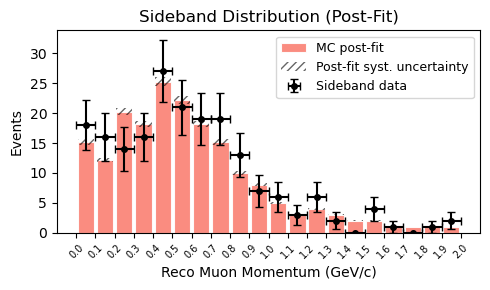

In [10]:
# ── Sideband post-fit toys ────────────────────────────────────────────────────
sb_postfit_toys = np.zeros((N_POSTFIT_TOYS, len(B_sb)))

for k in range(N_POSTFIT_TOYS):
    p = params_best + L_chol @ np.random.randn(N_PARAMS)
    p[:N_TRUE] = np.maximum(p[:N_TRUE], 1e-4)
    sb_postfit_toys[k] = forward_model_sideband(p)

sb_postfit_mean = np.mean(sb_postfit_toys, axis=0)
sb_postfit_std = np.std(sb_postfit_toys, axis=0)

# ── Sideband post-fit plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(
    reco_centers, forward_model_sideband(params_best),
    width=reco_bin_widths * 0.85,
    color='salmon', alpha=0.9, edgecolor='white', linewidth=0.8, label='MC post-fit',
)
ax.bar(
    reco_centers, 2 * sb_postfit_std,
    width=reco_bin_widths * 0.85,
    bottom=sb_postfit_mean - sb_postfit_std,
    color='none', edgecolor='black', linewidth=0.0,
    hatch='////', alpha=0.6, label='Post-fit syst. uncertainty',
)
ax.errorbar(
    reco_centers, N_sb_data,
    yerr=np.sqrt(N_sb_data), xerr=reco_bin_widths / 2,
    fmt='ko', markersize=4, capsize=3, label='Sideband data',
)
ax.set_xlabel('Reco Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Sideband Distribution (Post-Fit)')
ax.set_xticks(reco_bin_edges)
ax.set_xticklabels([f'{x:.1f}' for x in reco_bin_edges], rotation=45, fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

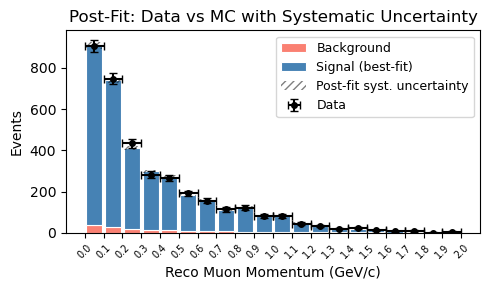

In [11]:
# ── Main fit post-fit toys ────────────────────────────────────────────────────
pred_postfit_toys = np.zeros((N_POSTFIT_TOYS, N_RECO))

for k in range(N_POSTFIT_TOYS):
    p = params_best + L_chol @ np.random.randn(N_PARAMS)
    p[:N_TRUE] = np.maximum(p[:N_TRUE], 1e-4)
    pred_postfit_toys[k] = forward_model(p)

postfit_mean = np.mean(pred_postfit_toys, axis=0)
postfit_std = np.std(pred_postfit_toys, axis=0)

# ── Post-fit signal region plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(
    reco_centers, B_j,
    width=reco_bin_widths * 0.85,
    color='salmon', edgecolor='white', linewidth=0.8, label='Background',
)
ax.bar(
    reco_centers, N_pred_best - B_j,
    width=reco_bin_widths * 0.85,
    bottom=B_j, color='steelblue', edgecolor='white', linewidth=0.8,
    label='Signal (best-fit)',
)
ax.bar(
    reco_centers, 2 * postfit_std,
    width=reco_bin_widths * 0.85,
    bottom=postfit_mean - postfit_std,
    color='none', edgecolor='black', linewidth=0.0,
    hatch='////', alpha=0.5, label='Post-fit syst. uncertainty',
)
ax.errorbar(
    reco_centers, N_data,
    yerr=np.sqrt(N_data), xerr=reco_bin_widths / 2,
    fmt='ko', markersize=4, capsize=3, label='Data',
)
ax.set_xlabel('Reco Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Post-Fit: Data vs MC with Systematic Uncertainty')
ax.set_xticks(reco_bin_edges)
ax.set_xticklabels([f'{x:.1f}' for x in reco_bin_edges], rotation=45, fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Pre-Post Fit Parameters
---

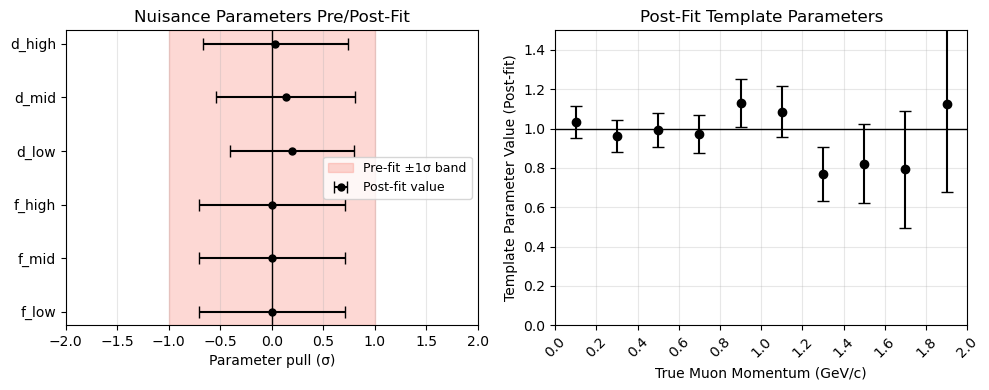

In [12]:
# ── Pre/post-fit parameter plots ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.axvspan(-1, 1, color='salmon', alpha=0.3, label='Pre-fit ±1σ band')
ax.errorbar(
    params_best[N_TRUE:] / sigmas[N_TRUE:],
    range(N_SYST),
    xerr=err[N_TRUE:] / sigmas[N_TRUE:],
    fmt='ko', markersize=5, capsize=4, linewidth=1.5, label='Post-fit value',
)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(N_SYST))
ax.set_yticklabels(['f_low', 'f_mid', 'f_high', 'd_low', 'd_mid', 'd_high'])
ax.set_xlabel('Parameter pull (σ)')
ax.set_title('Nuisance Parameters Pre/Post-Fit')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-2, 2)

ax = axes[1]
ax.axhline(1.0, color='black', linewidth=1)
ax.errorbar(
    true_centers, params_best[:N_TRUE],
    yerr=err[:N_TRUE],
    fmt='ko', markersize=6, capsize=4, linewidth=1.5,
)
ax.set_xlabel('True Muon Momentum (GeV/c)')
ax.set_ylabel('Template Parameter Value (Post-fit)')
ax.set_title('Post-Fit Template Parameters')
ax.set_xticks(true_bin_edges)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Cross-Section Extraction
---
We want to convert the fit result (the template parameters $c_i$)
into a physical **differential cross section** $d\sigma/dp$,
the probability of a CC0π interaction producing a muon with
momentum in bin $i$. $$\frac{d\sigma}{dp}\bigg|_i = \frac{N_i^\text{signal}}{\Delta p_i \cdot \Phi \cdot N_T}$$
where each ingredient has a clear physical meaning:

| Symbol | Value | Meaning |
|:------:|------:|---------|
| $N_i^\text{signal}$ | from fit | efficiency-corrected signal events in truth bin $i$ |
| $\Delta p_i$ | 0.2 GeV/c | truth bin width |
| $\Phi$ | $1.142 \times 10^{11}$ ν/cm² | integrated NuMI flux |
| $N_T$ | $4.714 \times 10^{30}$ | number of argon target nuclei |

The fit does not directly give us truth-level signal counts — it gives
us template weights $c_i$ and systematics $f_\text{low/mid/high}$.
We reconstruct the truth-level count as:

$$N_i^\text{signal} = c_i \cdot w_i^\text{interaction} \cdot N_i^\text{MC,gen}$$

- $N_i^\text{MC,gen}$ is the nominal MC prediction in truth bin $i$
- $w_i^\text{flux} = 1 + f_\text{group}$ corrects for the best-fit flux shift
- $c_i$ rescales the MC to match the data — this is the physics signal

In [13]:
# Normalization constants
PHI_FLUX = 1.142e11   # integrated neutrino flux [ν / cm²]
N_TARGET = 4.714e30   # number of argon target nuclei

# Interaction weights evaluated at best-fit systematic values
f_low, f_mid, f_high = params_best[N_TRUE:N_TRUE + 3]
int_w1_best = np.array([
    1 + f_low,  1 + f_low,  1 + f_low,              # T1–T3
    1 + f_mid,  1 + f_mid,  1 + f_mid,  1 + f_mid,  # T4–T7
    1 + f_high, 1 + f_high, 1 + f_high,             # T8–T10
])

# Efficiency-corrected truth-level signal counts per bin
c_best = params_best[:N_TRUE]
N_signal_truth = c_best * int_w1_best * N_true_gen

# Differential cross section: dσ/dp = N_signal / (Δp · Φ · N_T)
xsec = N_signal_truth / (true_bin_widths * PHI_FLUX * N_TARGET)

# ── Cross-section table ───────────────────────────────────────────────────────
print(f"{'Bin':>4}  {'p range':>14}  {'N_signal':>10}  {'dσ/dp [cm²/(GeV/c)/Ar]':>26}")
print("-" * 60)
for i, (lo, hi, n_sig, xs) in enumerate(
    zip(true_bin_edges[:-1], true_bin_edges[1:], N_signal_truth, xsec)
):
    print(f"  T{i + 1:<2}  [{lo:.2f}, {hi:.2f}]  {n_sig:>10.2f}  {xs:>26.3e}")

 Bin         p range    N_signal      dσ/dp [cm²/(GeV/c)/Ar]
------------------------------------------------------------
  T1   [0.00, 0.20]     1839.35                   1.708e-38
  T2   [0.20, 0.40]      665.14                   6.178e-39
  T3   [0.40, 0.60]      441.77                   4.103e-39
  T4   [0.60, 0.80]      247.64                   2.300e-39
  T5   [0.80, 1.00]      181.00                   1.681e-39
  T6   [1.00, 1.20]      124.92                   1.160e-39
  T7   [1.20, 1.40]       53.86                   5.003e-40
  T8   [1.40, 1.60]       32.87                   3.053e-40
  T9   [1.60, 1.80]       15.85                   1.473e-40
  T10  [1.80, 2.00]       11.25                   1.045e-40


### Toy Throwing and Total Uncertainty
---
The Hessian gives us $V_\text{main}$ — the parameter covariance matrix.
But we need to **propagate those parameter uncertainties through the
cross-section formula**, which is a non-linear function of the parameters.
Toy throwing does this propagation correctly without assuming linearity.

For each toy $k$ we:

1. **Sample a parameter vector** from the post-fit distribution:
$$\vec{\theta}_\text{toy} = \hat{\theta} + L \cdot \vec{z}, \quad \vec{z} \sim \mathcal{N}(0, I)$$

2. **Enforce physical bounds** — template weights must be positive:
$$c_i^\text{toy} = \max(c_i^\text{toy},\ 10^{-4})$$

3. **Compute a cross-section** for that toy:
$$\frac{d\sigma}{dp}\bigg|_i^\text{toy} = \frac{c_i^\text{toy} \cdot w_i^\text{flux,toy} \cdot N_i^\text{MC,gen}}{\Delta p_i \cdot \Phi \cdot N_T}$$

4. **Repeat** $N=2000$ times and take the spread across toys as the uncertainty:
$$\sigma_i = \text{std}\left(\frac{d\sigma}{dp}\bigg|_i^\text{toy}\right)$$

This computation requires the file `config_CalcXSec_FakeData_dpT.yaml` to be run by:

```bash
gundamCalcXsec -c {cross section .yaml file} -f {fitter yaml file path as input} -n {number of universes} -o {output path} --use-bf-as-xsec
```
For example:
```bash
gundamCalcXsec -c config_CalcXSec_FakeData_dpT.yaml -f asimov_dpT.root -n 10000 -o XSec_dpT.root --use-bf-as-xsec
```

Throwing 2000 toys...

 Bin         p range           dσ/dp             ±   Rel. unc.
--------------------------------------------------------------
  T1   [0.00, 0.20]       1.701e-38  ±6.177e-40        3.6%
  T2   [0.20, 0.40]       6.148e-39  ±2.911e-40        4.7%
  T3   [0.40, 0.60]       4.086e-39  ±2.155e-40        5.3%
  T4   [0.60, 0.80]       2.285e-39  ±1.640e-40        7.2%
  T5   [0.80, 1.00]       1.677e-39  ±1.396e-40        8.3%
  T6   [1.00, 1.20]       1.150e-39  ±1.103e-40        9.6%
  T7   [1.20, 1.40]       4.986e-40  ±8.154e-41       16.4%
  T8   [1.40, 1.60]       3.058e-40  ±6.990e-41       22.9%
  T9   [1.60, 1.80]       1.472e-40  ±5.396e-41       36.7%
  T10  [1.80, 2.00]       1.036e-40  ±4.081e-41       39.4%


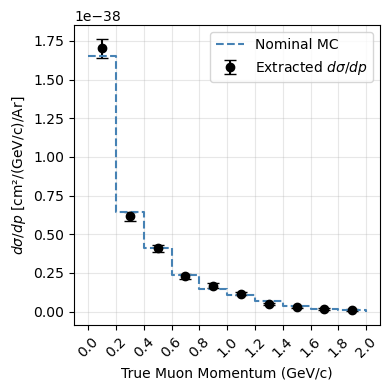

In [14]:
N_TOYS = 2000
print(f"Throwing {N_TOYS} toys...")

xsec_toys = np.zeros((N_TOYS, N_TRUE))
for k in range(N_TOYS):
    p = params_best + L_chol @ np.random.randn(N_PARAMS)
    p[:N_TRUE] = np.maximum(p[:N_TRUE], 1e-4)

    c_toy = p[:N_TRUE]
    f_toy = p[N_TRUE:N_TRUE + 3]
    fw_toy = np.array([
        1 + f_toy[0], 1 + f_toy[0], 1 + f_toy[0],              # T1–T3
        1 + f_toy[1], 1 + f_toy[1], 1 + f_toy[1], 1 + f_toy[1],  # T4–T7
        1 + f_toy[2], 1 + f_toy[2], 1 + f_toy[2],              # T8–T10
    ])
    N_sig_toy = c_toy * fw_toy * N_true_gen
    xsec_toys[k] = N_sig_toy / (true_bin_widths * PHI_FLUX * N_TARGET)

xsec_mean = np.mean(xsec_toys, axis=0)
xsec_std = np.std(xsec_toys, axis=0)

# ── Uncertainty table ─────────────────────────────────────────────────────────
print(f"\n{'Bin':>4}  {'p range':>14}  {'dσ/dp':>14}  {'±':>12}  {'Rel. unc.':>10}")
print("-" * 62)
for i, (lo, hi, mean, std) in enumerate(
    zip(true_bin_edges[:-1], true_bin_edges[1:], xsec_mean, xsec_std)
):
    rel = std / mean * 100
    print(f"  T{i + 1:<2}  [{lo:.2f}, {hi:.2f}]  {mean:>14.3e}  ±{std:.3e}  {rel:>9.1f}%")

# ── Cross-section plot ────────────────────────────────────────────────────────
xsec_nominal = N_true_gen / (true_bin_widths * PHI_FLUX * N_TARGET)

fig, ax = plt.subplots(figsize=(4, 4))
ax.errorbar(
    true_centers, xsec_mean,
    yerr=xsec_std,
    fmt='ko', markersize=6, capsize=4, linewidth=1.5,
    label=r'Extracted $d\sigma/dp$',
)
ax.step(
    true_bin_edges, np.append(xsec_nominal, 0),
    where='post', color='steelblue', linestyle='--', linewidth=1.5,
    label='Nominal MC',
)
ax.set_xlabel('True Muon Momentum (GeV/c)')
ax.set_ylabel(r'$d\sigma/dp$ [cm²/(GeV/c)/Ar]')
ax.set_xticks(true_bin_edges)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()